<a href="https://colab.research.google.com/github/sabnamfardish/Plant-Disease-Detection-And-Classification-Using-Deep-Learning-With-EfficientNetB4/blob/main/plant_disease_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title
!wget -O "dataset.zip"  "https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded"

--2026-04-26 17:11:34--  https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.130.86, 162.159.133.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.130.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/349ac012-2948-4172-bbba-3bf8f76596fd [following]
--2026-04-26 17:11:35--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/349ac012-2948-4172-bbba-3bf8f76596fd
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 3.5.64.196, 52.92.20.194, 3.5.74.80, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|3.5.64.196|:443... con

In [ ]:
!unzip /content/dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (132).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1320).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1321).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1322).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1323).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1324).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1325).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1326).JPG  
  infl

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

In [ ]:
!pip install split-folders

In [ ]:
import splitfolders
splitfolders.ratio('/content/Plant_leave_diseases_dataset_with_augmentation', output="dataset", seed= 1337,ratio=(.8,.1,.1))

Copying files: 61486 files [00:15, 3936.85 files/s]


# DATA PREPROCESSING

In [ ]:
train_dir = "/content/dataset/train"
validation_dir = "/content/dataset/val"

BATCH_SIZE = 32
IMG_SIZE = (160, 160)

train_dataset = tf.keras.utils.image_dataset_from_directory(train_dir,
                                                            shuffle=True,
                                                            batch_size=BATCH_SIZE,
                                                            image_size=IMG_SIZE)


Found 49179 files belonging to 39 classes.


In [ ]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(validation_dir,
                                                                 shuffle=True,
                                                                 batch_size=BATCH_SIZE,
                                                                 image_size=IMG_SIZE)
test_dir="/content/dataset/test"
test_dataset=tf.keras.utils.image_dataset_from_directory(test_dir,
                                                                 batch_size=BATCH_SIZE,
                                                                 image_size=IMG_SIZE)

Found 6139 files belonging to 39 classes.
Found 6168 files belonging to 39 classes.


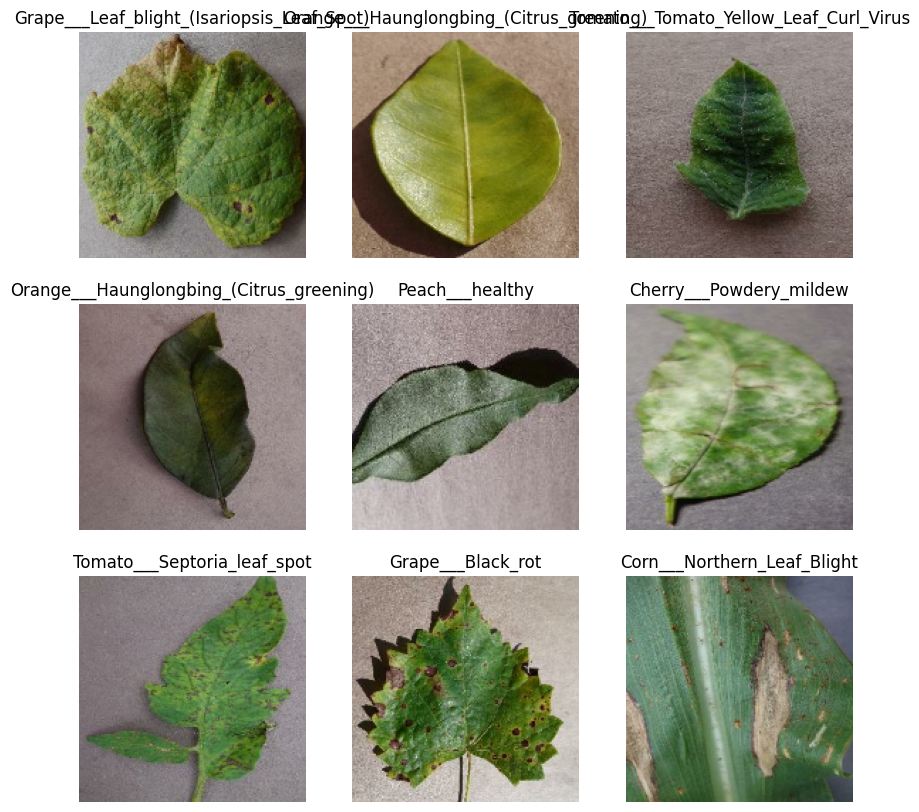

In [ ]:
class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
class_names

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Background_without_leaves',
 'Blueberry___healthy',
 'Cherry___Powdery_mildew',
 'Cherry___healthy',
 'Corn___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn___Common_rust',
 'Corn___Northern_Leaf_Blight',
 'Corn___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot'

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [ ]:
preprocess_input = tf.keras.applications.efficientnet.preprocess_input

In [ ]:
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.EfficientNetB4(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet',
)

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 5, 5, 1792)


### **Feature extraction**
Freeze the convolutional base

In [ ]:
base_model.trainable = False

In [ ]:
base_model.summary()

Model: "efficientnetb4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 160, 160,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 160, 160,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 160, 160,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 161, 161,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 80, 80,    │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 80, 80,    │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 80, 80,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 80, 80,    │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 80, 80,    │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 80, 80,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 80, 80,    │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 80, 80,    │      1,152 │ block1a_se_excit

 Total params: 17,673,823 (67.42 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 17,673,823 (67.42 MB)

In [ ]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1792)


In [ ]:
prediction_layer = tf.keras.layers.Dense(len(class_names), activation='sigmoid')
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 39)


In [ ]:
inputs = tf.keras.Input(shape=(160, 160, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 5, 5, 1792)     │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 39)             │        69,927 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,743,750 (67.69 MB)

 Trainable params: 69,927 (273.15 KB)

 Non-trainable params: 17,673,823 (67.42 MB)

In [ ]:
len(model.trainable_variables)

2

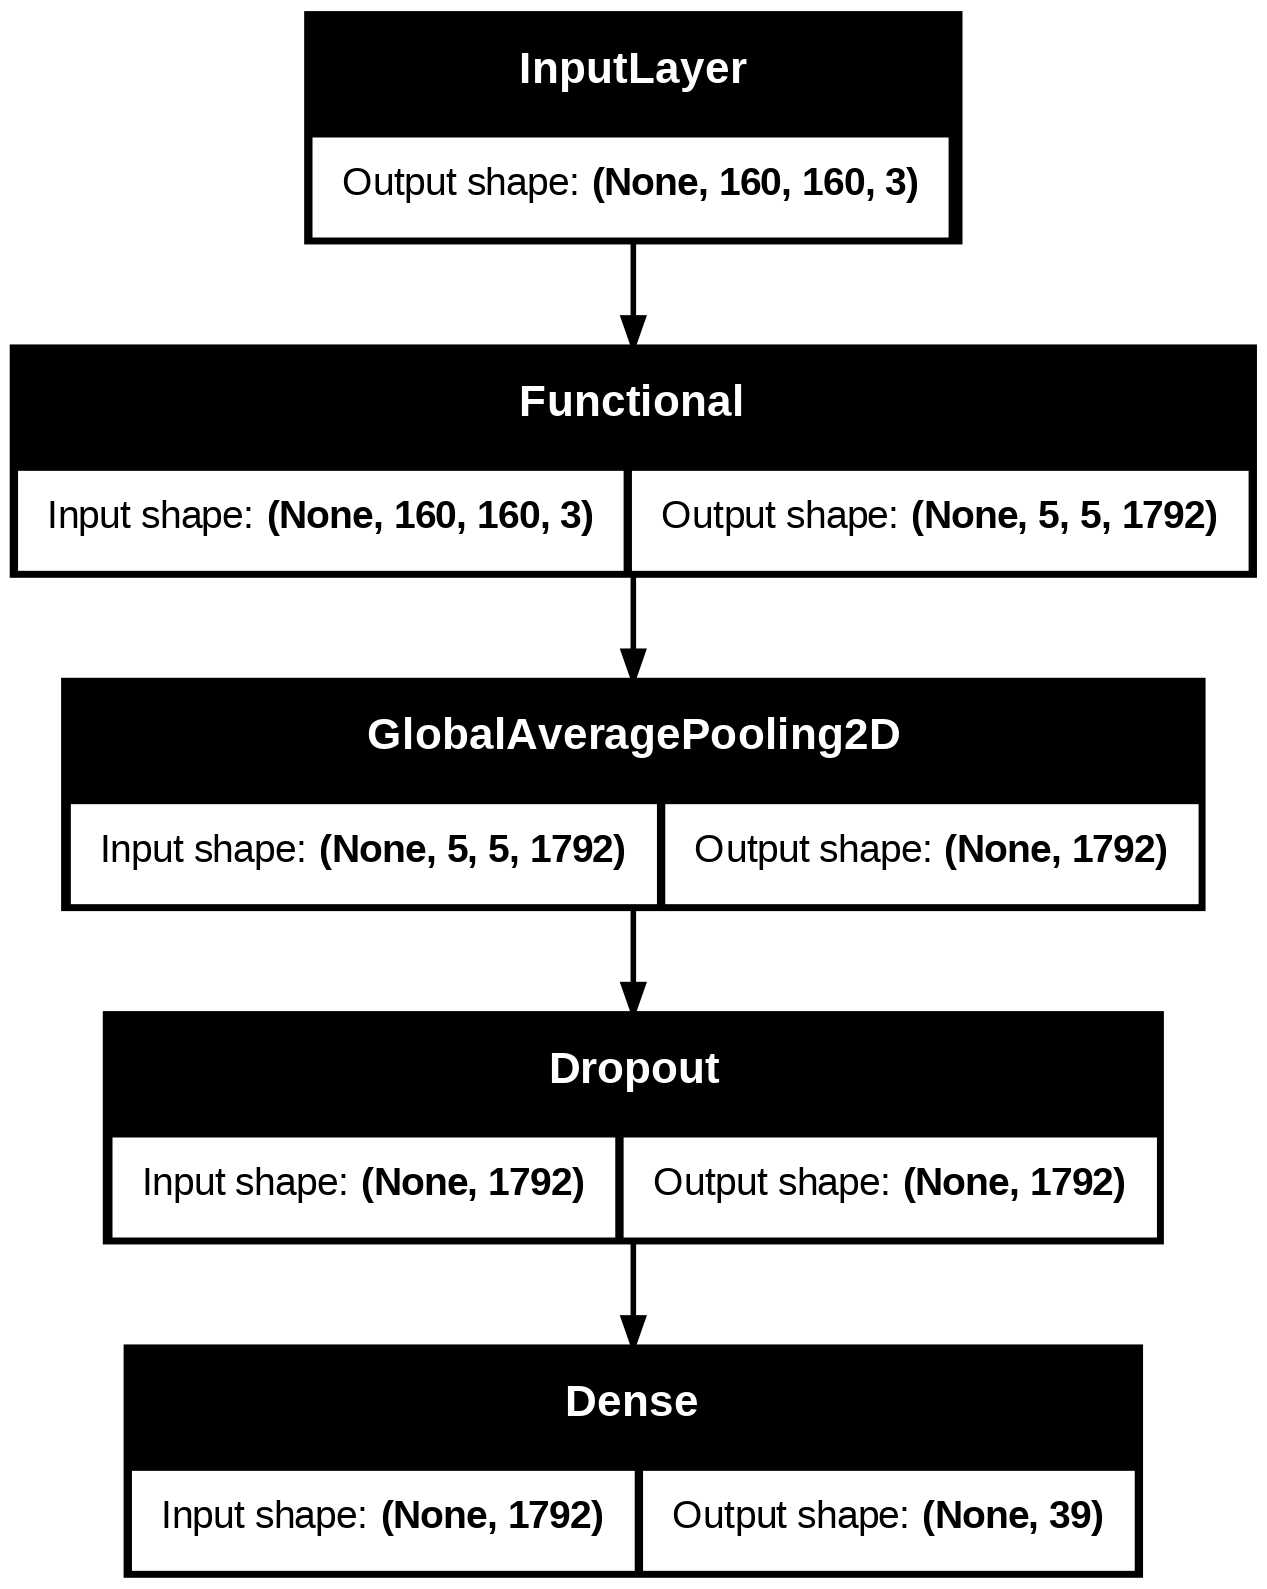

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')])

In [ ]:
initial_epochs = 6

loss0, accuracy0 = model.evaluate(validation_dataset)

192/192 ━━━━━━━━━━━━━━━━━━━━ 49s 135ms/step - accuracy: 0.0103 - loss: 3.7745


In [ ]:
print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

initial loss: 3.77
initial accuracy: 0.01


In [ ]:
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset)

Epoch 1/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 154s 72ms/step - accuracy: 0.8175 - loss: 0.7107 - val_accuracy: 0.9129 - val_loss: 0.3202
Epoch 2/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 101s 61ms/step - accuracy: 0.9078 - loss: 0.3165 - val_accuracy: 0.9345 - val_loss: 0.2315
Epoch 3/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 144s 62ms/step - accuracy: 0.9249 - loss: 0.2517 - val_accuracy: 0.9401 - val_loss: 0.1967
Epoch 4/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 95s 62ms/step - accuracy: 0.9328 - loss: 0.2196 - val_accuracy: 0.9467 - val_loss: 0.1755
Epoch 5/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 96s 63ms/step - accuracy: 0.9379 - loss: 0.1974 - val_accuracy: 0.9498 - val_loss: 0.1584
Epoch 6/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 95s 62ms/step - accuracy: 0.9422 - loss: 0.1827 - val_accuracy: 0.9513 - val_loss: 0.1480


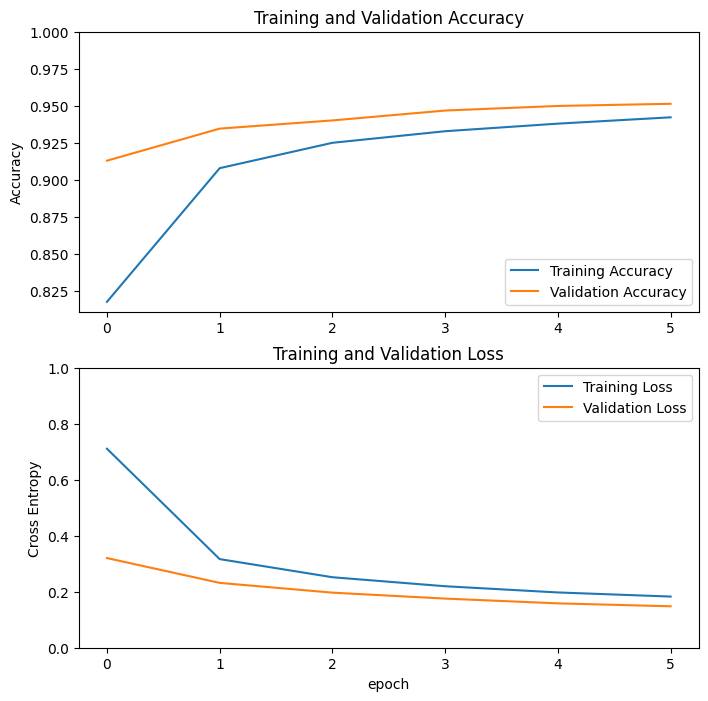

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

## **Fine tuning**

In [ ]:
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  475


In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')])

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 5, 5, 1792)     │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 39)             │        69,927 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,743,750 (67.69 MB)

 Trainable params: 69,927 (273.15 KB)

 Non-trainable params: 17,673,823 (67.42 MB)

In [ ]:
len(model.trainable_variables)

2

In [ ]:
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = model.fit(train_dataset,
                         epochs=total_epochs,
                         initial_epoch=len(history.epoch),
                         validation_data=validation_dataset)

Epoch 7/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 197s 100ms/step - accuracy: 0.9426 - loss: 0.1769 - val_accuracy: 0.9544 - val_loss: 0.1368
Epoch 8/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 95s 62ms/step - accuracy: 0.9449 - loss: 0.1673 - val_accuracy: 0.9572 - val_loss: 0.1320
Epoch 9/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 112s 73ms/step - accuracy: 0.9447 - loss: 0.1620 - val_accuracy: 0.9570 - val_loss: 0.1275
Epoch 10/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 99s 64ms/step - accuracy: 0.9447 - loss: 0.1581 - val_accuracy: 0.9576 - val_loss: 0.1243
Epoch 11/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 94s 61ms/step - accuracy: 0.9470 - loss: 0.1512 - val_accuracy: 0.9578 - val_loss: 0.1259
Epoch 12/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 94s 61ms/step - accuracy: 0.9455 - loss: 0.1497 - val_accuracy: 0.9573 - val_loss: 0.1178
Epoch 13/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 141s 61ms/step - accuracy: 0.9472 - loss: 0.1448 - val_accuracy: 0.9583 - val_loss: 0.1156
Epoch 14/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 144s 62ms/step - accuracy

In [ ]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

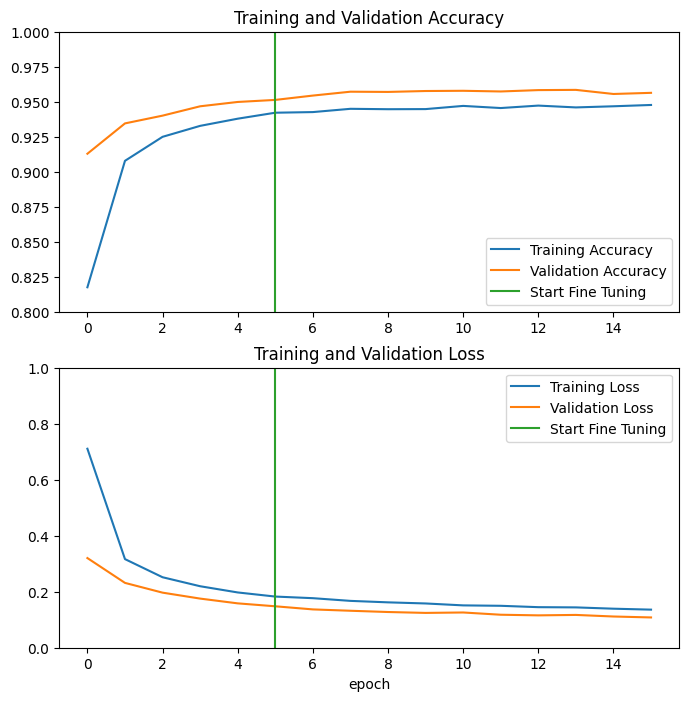

In [ ]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [ ]:
loss, accuracy = model.evaluate(test_dataset)
print('Test accuracy :', accuracy)

193/193 ━━━━━━━━━━━━━━━━━━━━ 26s 137ms/step - accuracy: 0.9627 - loss: 0.1034
Test accuracy : 0.9627107381820679


Predictions:
 [32  7 12  0 27 25 18  3 22 36 25 26  4 13 17 12 31 14 29 29 16 31  5 25
 29 33 16 38 31 36 29  0]
Labels:
 [32  7 12  0 27 25 18  3 22 36 25 26  4 13 17 12 32 14 29 29 16 30  5 25
 29 33 16 38  0 36 29  0]


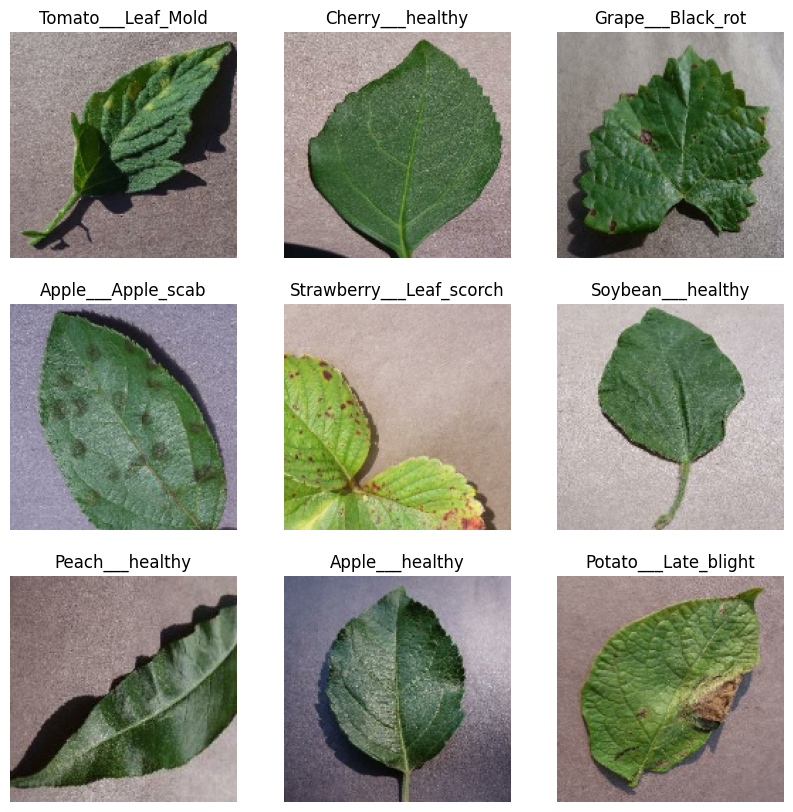

In [ ]:
# Retrieve a batch of images from the test set
image_batch, label_batch = test_dataset.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch)
predictions = tf.argmax(predictions,axis=1)

print('Predictions:\n', predictions.numpy())
print('Labels:\n', label_batch)

plt.figure(figsize=(10, 10))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  plt.title(class_names[predictions[i]])
  plt.axis("off")

In [ ]:
model.save("plant_disease_recog_model_pwp.keras")

CONFUSION MATRIX

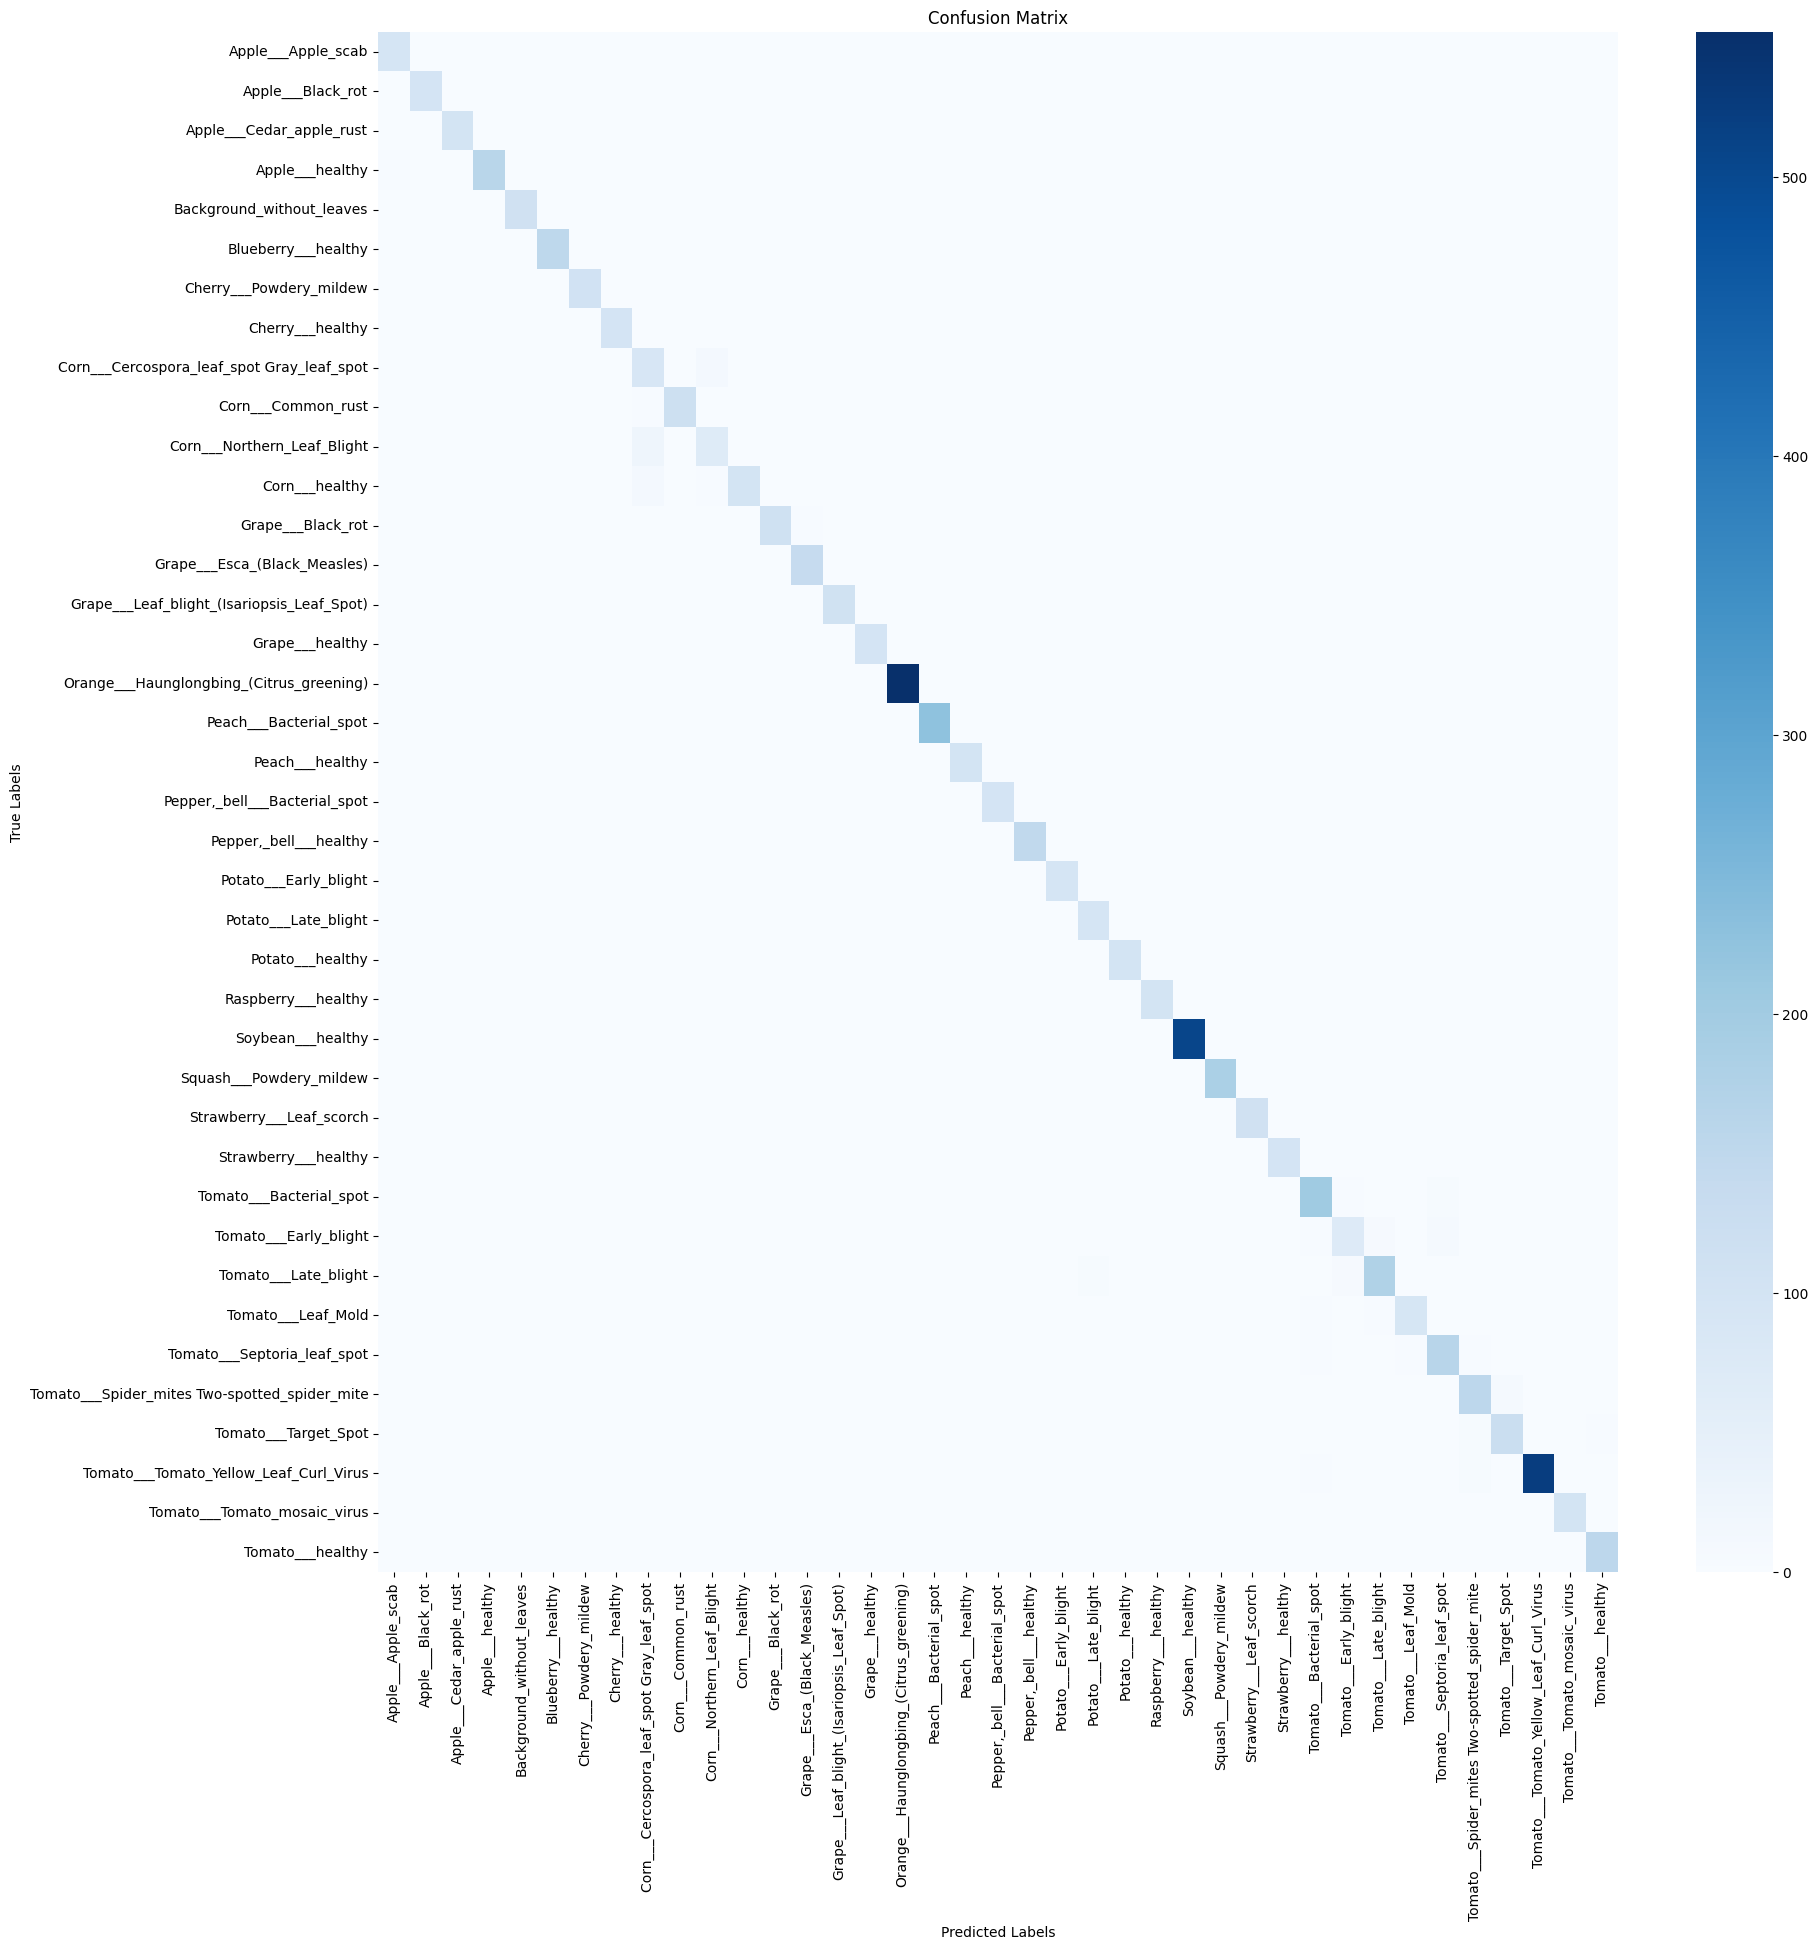

Classification Report:

                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.95      0.97      0.96       100
                            Apple___Black_rot       0.98      0.98      0.98       100
                     Apple___Cedar_apple_rust       0.95      1.00      0.98       100
                              Apple___healthy       0.99      0.97      0.98       165
                    Background_without_leaves       1.00      0.96      0.98       115
                          Blueberry___healthy       0.97      1.00      0.99       151
                      Cherry___Powdery_mildew       1.00      1.00      1.00       106
                             Cherry___healthy       0.99      0.98      0.98       100
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.68      0.89      0.77       100
                           Corn___Common_rust       0.98      0.97      0.98       120
                  

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(20, 20))
sns.heatmap(cm,
            annot=False,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Classification Report (Precision, Recall, F1-score)
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

F1 SCORE

In [ ]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images)
    preds = tf.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.numpy())

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/

Tomata Confusion Matrix

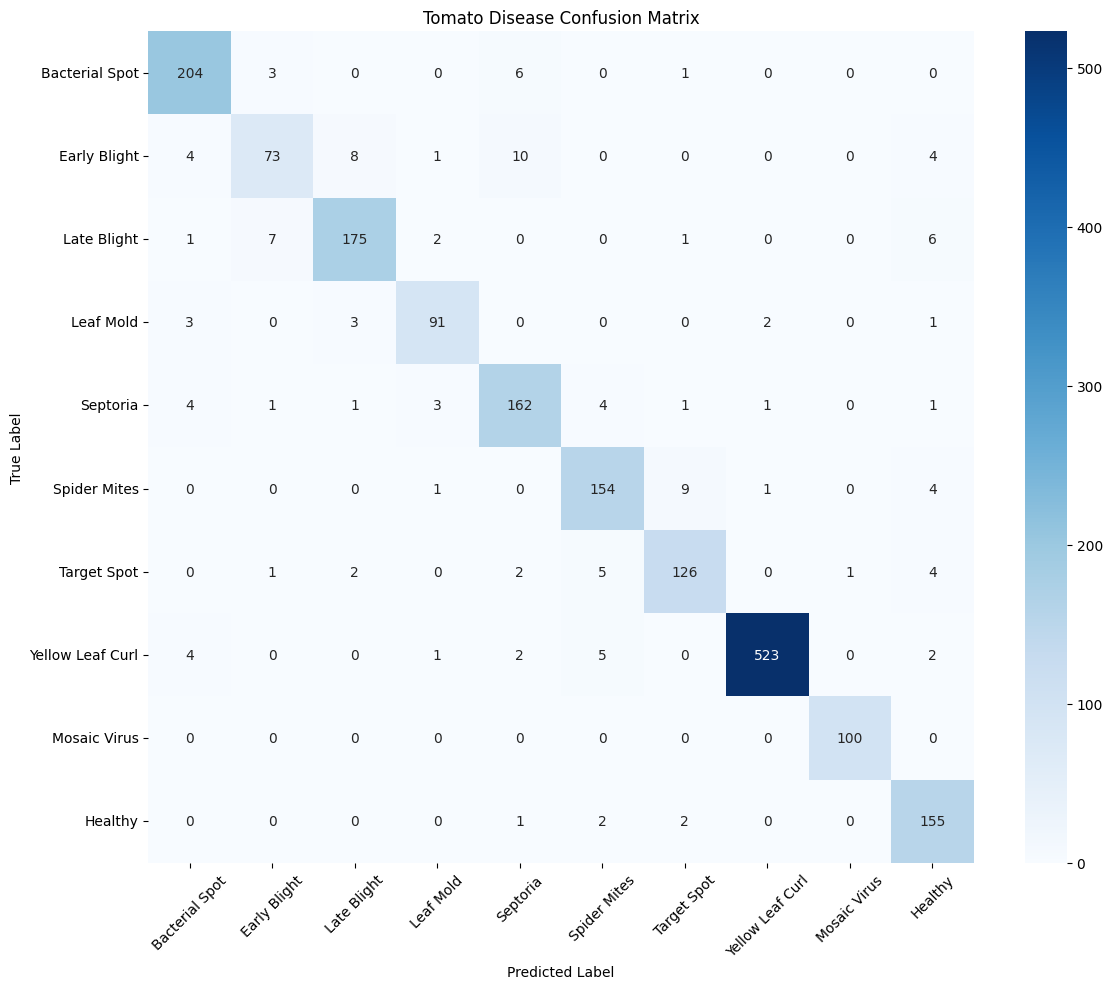

Tomato Disease Classification Report:

                  precision    recall  f1-score   support

  Bacterial Spot       0.93      0.95      0.94       214
    Early Blight       0.86      0.73      0.79       100
     Late Blight       0.93      0.91      0.92       192
       Leaf Mold       0.92      0.91      0.91       100
        Septoria       0.89      0.91      0.90       178
    Spider Mites       0.91      0.91      0.91       169
     Target Spot       0.90      0.89      0.90       141
Yellow Leaf Curl       0.99      0.97      0.98       537
    Mosaic Virus       0.99      1.00      1.00       100
         Healthy       0.88      0.97      0.92       160

        accuracy                           0.93      1891
       macro avg       0.92      0.92      0.92      1891
    weighted avg       0.93      0.93      0.93      1891



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Tomato classes only from PlantVillage dataset
tomato_classes = [
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]

# Get class indices of only tomato classes
tomato_indices = [class_names.index(cls) for cls in tomato_classes]

# Store true and predicted labels
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for true_label, pred_label in zip(labels.numpy(), predicted_labels):

        # Keep only tomato class samples
        if true_label in tomato_indices:
            y_true.append(true_label)
            y_pred.append(pred_label)

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Convert original labels to tomato-only labels (0 to 9)
label_map = {old: new for new, old in enumerate(tomato_indices)}

y_true = np.array([label_map[label] for label in y_true])

# For prediction labels:
# If predicted class is not tomato class, mark as nearest safe class
y_pred_filtered = []

for label in y_pred:
    if label in tomato_indices:
        y_pred_filtered.append(label_map[label])
    else:
        # optional fallback: assign as healthy
        y_pred_filtered.append(len(tomato_classes) - 1)

y_pred = np.array(y_pred_filtered)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Bacterial Spot',
        'Early Blight',
        'Late Blight',
        'Leaf Mold',
        'Septoria',
        'Spider Mites',
        'Target Spot',
        'Yellow Leaf Curl',
        'Mosaic Virus',
        'Healthy'
    ],
    yticklabels=[
        'Bacterial Spot',
        'Early Blight',
        'Late Blight',
        'Leaf Mold',
        'Septoria',
        'Spider Mites',
        'Target Spot',
        'Yellow Leaf Curl',
        'Mosaic Virus',
        'Healthy'
    ]
)

plt.title("Tomato Disease Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification report
print("Tomato Disease Classification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=[
        'Bacterial Spot',
        'Early Blight',
        'Late Blight',
        'Leaf Mold',
        'Septoria',
        'Spider Mites',
        'Target Spot',
        'Yellow Leaf Curl',
        'Mosaic Virus',
        'Healthy'
    ]
))

Others


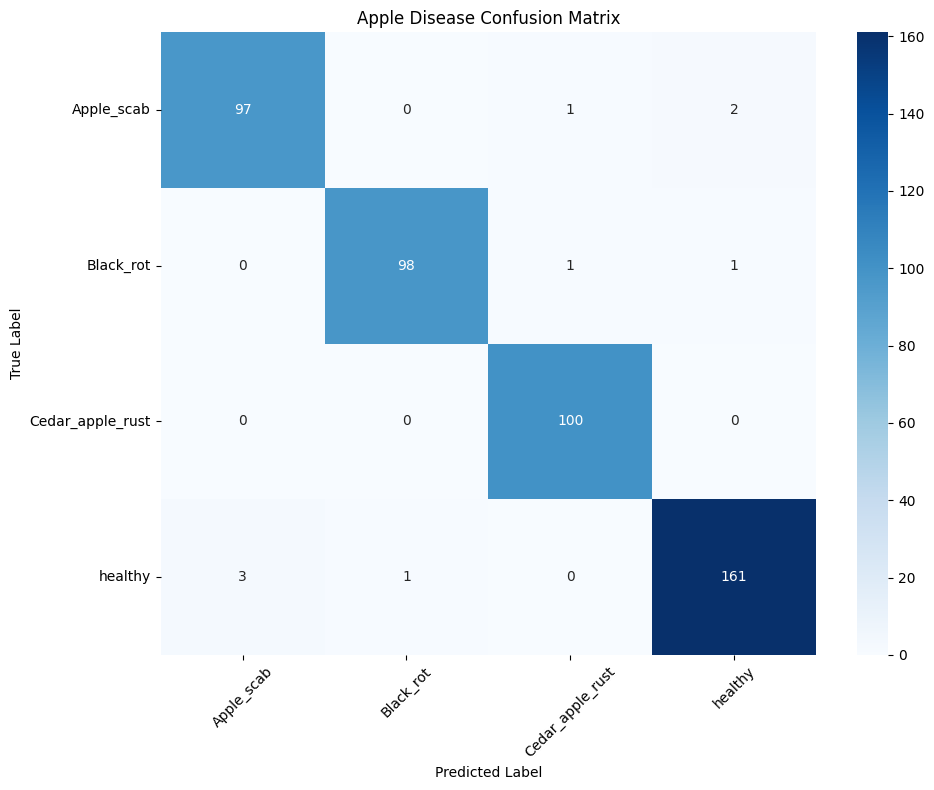


Apple Classification Report:

                  precision    recall  f1-score   support

      Apple_scab       0.97      0.97      0.97       100
       Black_rot       0.99      0.98      0.98       100
Cedar_apple_rust       0.98      1.00      0.99       100
         healthy       0.98      0.98      0.98       165

        accuracy                           0.98       465
       macro avg       0.98      0.98      0.98       465
    weighted avg       0.98      0.98      0.98       465



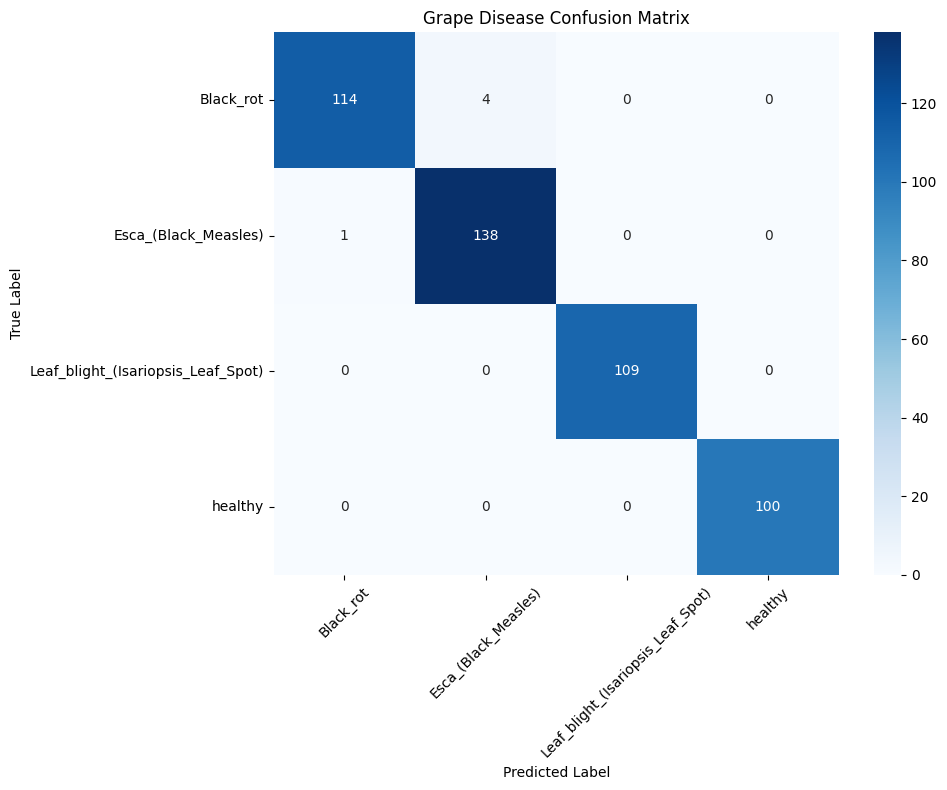


Grape Classification Report:

                                    precision    recall  f1-score   support

                         Black_rot       0.99      0.97      0.98       118
              Esca_(Black_Measles)       0.97      0.99      0.98       139
Leaf_blight_(Isariopsis_Leaf_Spot)       1.00      1.00      1.00       109
                           healthy       1.00      1.00      1.00       100

                          accuracy                           0.99       466
                         macro avg       0.99      0.99      0.99       466
                      weighted avg       0.99      0.99      0.99       466



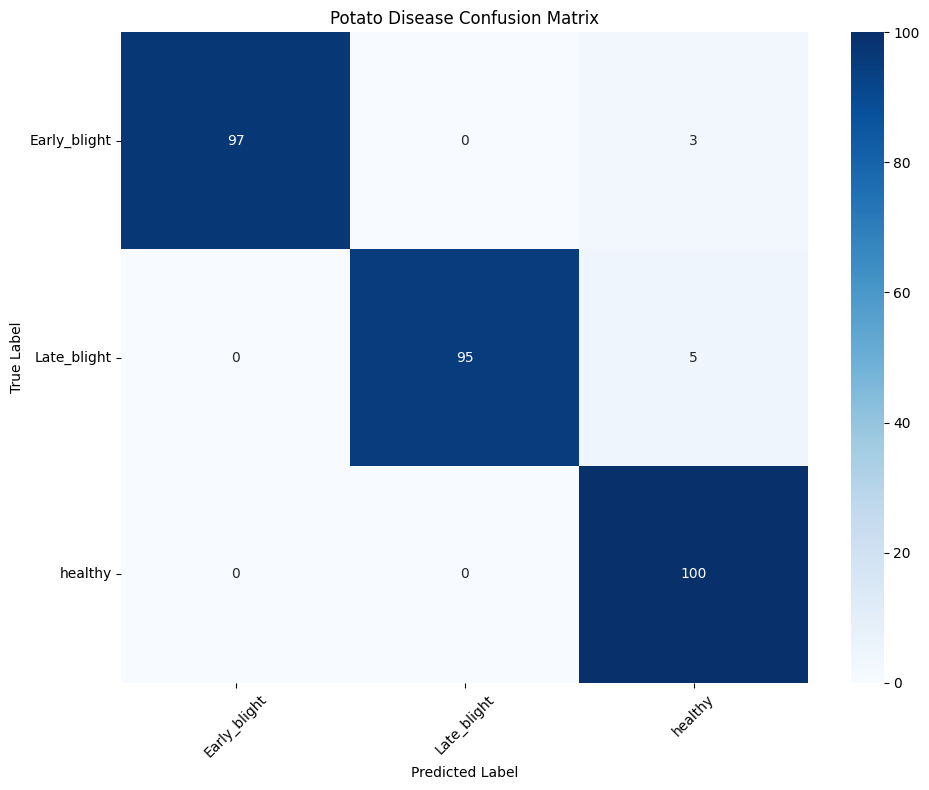


Potato Classification Report:

              precision    recall  f1-score   support

Early_blight       1.00      0.97      0.98       100
 Late_blight       1.00      0.95      0.97       100
     healthy       0.93      1.00      0.96       100

    accuracy                           0.97       300
   macro avg       0.98      0.97      0.97       300
weighted avg       0.98      0.97      0.97       300



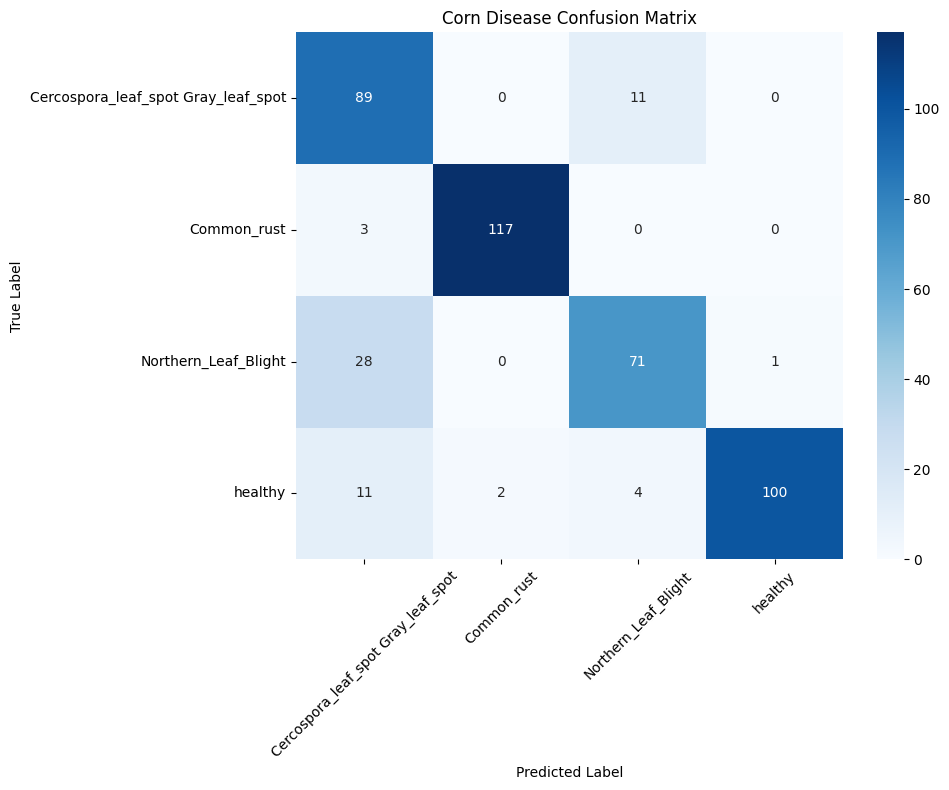


Corn Classification Report:

                                     precision    recall  f1-score   support

Cercospora_leaf_spot Gray_leaf_spot       0.68      0.89      0.77       100
                        Common_rust       0.98      0.97      0.98       120
               Northern_Leaf_Blight       0.83      0.71      0.76       100
                            healthy       0.99      0.85      0.92       117

                           accuracy                           0.86       437
                          macro avg       0.87      0.86      0.86       437
                       weighted avg       0.88      0.86      0.87       437



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# =====================================================
# FUNCTION: Plot confusion matrix for selected crop
# =====================================================

def plot_crop_confusion_matrix(crop_name, crop_classes):

    # Get class indexes from full dataset
    crop_indices = [class_names.index(cls) for cls in crop_classes]

    y_true = []
    y_pred = []

    # Get predictions
    for images, labels in test_dataset:
        predictions = model.predict(images, verbose=0)
        predicted_labels = np.argmax(predictions, axis=1)

        for true_label, pred_label in zip(labels.numpy(), predicted_labels):
            if true_label in crop_indices:
                y_true.append(true_label)
                y_pred.append(pred_label)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Convert labels to 0...n
    label_map = {old: new for new, old in enumerate(crop_indices)}

    y_true = np.array([label_map[label] for label in y_true])

    y_pred_new = []
    for label in y_pred:
        if label in crop_indices:
            y_pred_new.append(label_map[label])
        else:
            y_pred_new.append(len(crop_classes) - 1)

    y_pred = np.array(y_pred_new)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot
    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[x.split("___")[1] for x in crop_classes],
        yticklabels=[x.split("___")[1] for x in crop_classes]
    )

    plt.title(f"{crop_name} Disease Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print(f"\n{crop_name} Classification Report:\n")
    print(classification_report(
        y_true,
        y_pred,
        target_names=[x.split("___")[1] for x in crop_classes]
    ))


# =====================================================
# APPLE
# =====================================================

apple_classes = [
    'Apple___Apple_scab',
    'Apple___Black_rot',
    'Apple___Cedar_apple_rust',
    'Apple___healthy'
]

plot_crop_confusion_matrix("Apple", apple_classes)


# =====================================================
# GRAPE
# =====================================================

grape_classes = [
    'Grape___Black_rot',
    'Grape___Esca_(Black_Measles)',
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'Grape___healthy'
]

plot_crop_confusion_matrix("Grape", grape_classes)


# =====================================================
# POTATO
# =====================================================

potato_classes = [
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy'
]

plot_crop_confusion_matrix("Potato", potato_classes)


# =====================================================
# CORN
# =====================================================

corn_classes = [
    'Corn___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn___Common_rust',
    'Corn___Northern_Leaf_Blight',
    'Corn___healthy'
]

plot_crop_confusion_matrix("Corn", corn_classes)